In [1]:
import pandas as pd
import numpy as np
import sklearn

In [2]:
PATH_TO_DATA = "data/solution_evaluation/clean/clean_v2.csv"

In [3]:
raw = pd.read_csv(PATH_TO_DATA)
raw.shape

(642, 28)

In [4]:
raw.head()

,sample_id,origin,augmentation_type,generation_basis,source_site,language,case_id,case_title,case_text,case_url,...,case_parser_mode,needs_review,retrieved_at,score_factchecking,score_originality,score_effectiveness,score_logic,score_completeness,score_total,evaluation_rationale
0,real_0001,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,100.0,75.0,85.0,80.0,80.0,84.0,Ключевой ход: Если подрядчик виноват в сдвижен...
1,real_0002,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,95.0,75.0,50.0,70.0,45.0,67.5,Ключевой ход: Либо при закупке оборудования ЦО...
2,real_0003,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,95.0,70.0,75.0,80.0,85.0,80.0,"Ключевой ход: Наверное, мое решение не будет о..."
3,real_0004,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,95.0,80.0,50.0,75.0,60.0,71.8,Ключевой ход: Что необходимо делать: - Тщатель...
4,real_0005,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,95.0,85.0,60.0,70.0,60.0,74.8,Ключевой ход: Что он поставляет и от чего зави...


In [5]:
raw.loc[raw['augmentation_type'].isnull(), 'augmentation_type'] = 'original'

In [6]:
raw['augmentation_type'].value_counts()

augmentation_type
original             438
low_factchecking      34
low_originality       34
low_effectiveness     34
low_logic             34
low_completeness      34
very_weak             34
Name: count, dtype: int64

In [7]:
raw.loc[raw['augmentation_type']=='very_weak']

,sample_id,origin,augmentation_type,generation_basis,source_site,language,case_id,case_title,case_text,case_url,...,case_parser_mode,needs_review,retrieved_at,score_factchecking,score_originality,score_effectiveness,score_logic,score_completeness,score_total,evaluation_rationale
443,syn_1982409_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,36.0,34.0,18.0,38.0,22.0,29.2,Ответ частично игнорирует прямой запрет на отк...
449,syn_1982400_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982400,Прощаться или нет с CEO?,Дано: генеральный директор требует существенно...,https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,49.0,28.0,21.0,43.0,30.0,33.0,Ответ упрощает рынок руководителей и недооцени...
455,syn_1982394_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982394,Как вернуть гостей в рестораны?,"Дано. Сеть ресторанов, работающая в сегменте «...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,41.0,51.0,17.0,44.0,26.0,35.7,"Некоторые маркетинговые идеи релевантны, но кл..."
461,syn_1982386_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982386,"Как не подставиться, поручившись за работника ...","Корпоративный кредит – льгота, которую компани...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,20.0,25.0,7.0,36.0,22.0,20.7,Предлагаются юридически и этически проблемные ...
467,syn_1982379_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982379,Как неизвестной компании выйти на федеральный ...,Стартовая ситуация\n\nНаша компания работает в...,https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,45.0,42.0,25.0,49.0,28.0,37.3,Ответ поверхностный: не учитывает ограничения ...
473,syn_1979833_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1979833,Антикризисный план для музея,Executive.ru часто пишет о проблемах российско...,https://www.e-xecutive.ru/education/cases/1979...,...,catalog_slug_match,False,NaN,55.0,46.0,28.0,51.0,24.0,40.8,"Есть одна понятная маркетинговая идея, но она ..."
479,syn_1915529_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1915529,Справедливое наказание или имидж – чем пожертв...,Участник Сообщества Executive.ru Павел Кульгин...,https://www.e-xecutive.ru/education/cases/1915...,...,linked_page,False,NaN,43.0,31.0,22.0,52.0,29.0,34.0,Ответ фактически предлагает замять подтвержден...
485,syn_1839851_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1839851,"Как спасти от банкротства предприятие, которое...","Сообщество менеджеров Executive.ru, Международ...",https://www.e-xecutive.ru/education/cases/1839...,...,linked_page,False,NaN,38.0,45.0,16.0,44.0,24.0,33.0,"Социальная вовлеченность сама по себе полезна,..."
491,syn_1829328_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1829328,Волк в овечьей шкуре,Участница Сообщества Executive.ru Анастасия Ти...,https://www.e-xecutive.ru/education/cases/1829...,...,linked_page,False,NaN,35.0,26.0,18.0,43.0,25.0,28.2,Решение основано на субъективном впечатлении и...
497,syn_1776591_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1776591,В погоне за двумя зайцами,Участник Сообщества Executive.ru Дмитрий Проск...,https://www.e-xecutive.ru/education/cases/1776...,...,linked_page,False,NaN,42.0,25.0,24.0,48.0,28.0,32.0,Ответ сводит сложную трансформацию к давлению ...


In [8]:
raw.columns

Index(['sample_id', 'origin', 'augmentation_type', 'generation_basis',
       'source_site', 'language', 'case_id', 'case_title', 'case_text',
       'case_url', 'solution_page_id', 'solution_page_url', 'solution_index',
       'solution_title', 'solution_author_raw', 'solution_text', 'is_winner',
       'parser_mode', 'case_parser_mode', 'needs_review', 'retrieved_at',
       'score_factchecking', 'score_originality', 'score_effectiveness',
       'score_logic', 'score_completeness', 'score_total',
       'evaluation_rationale'],
      dtype='object')

In [9]:
cols = ['case_id', 'is_winner', 'sample_id', 'origin', 'case_title', 'case_text', 'solution_text', 'score_factchecking', 'score_originality', 'score_effectiveness', 'score_logic', 'score_completeness', 'score_total']

In [10]:
df = raw.copy()[cols]
df

,case_id,is_winner,sample_id,origin,case_title,case_text,solution_text,score_factchecking,score_originality,score_effectiveness,score_logic,score_completeness,score_total
0,1982409,True,real_0001,real,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",Перед запуском любого проекта составляется так...,100.0,75.0,85.0,80.0,80.0,84.0
1,1982409,False,real_0002,real,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",Грамотный квалифицированный подрядчик должен н...,95.0,75.0,50.0,70.0,45.0,67.5
2,1982409,False,real_0003,real,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",В ситуации непонятны некоторые моменты: с одно...,95.0,70.0,75.0,80.0,85.0,80.0
3,1982409,False,real_0004,real,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",Главной базовой проблемой заказчика является н...,95.0,80.0,50.0,75.0,60.0,71.8
4,1982409,False,real_0005,real,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",Вечная проблема: беда кроется в монополизме.\n...,95.0,85.0,60.0,70.0,60.0,74.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,661498,False,syn_661498_02,synthetic,Защита Дюжина,Executive.ru представляет новый кейс в рамках ...,Дюжину не стоит превращать заседание только в ...,95.0,40.0,85.0,91.0,87.0,77.0
638,661498,False,syn_661498_03,synthetic,Защита Дюжина,Executive.ru представляет новый кейс в рамках ...,"Чтобы гарантировать защиту, Дюжин может нанять...",83.0,74.0,20.0,67.0,78.0,61.9
639,661498,False,syn_661498_04,synthetic,Защита Дюжина,Executive.ru представляет новый кейс в рамках ...,Дюжин должен показать совету абсолютную лояльн...,81.0,58.0,26.0,15.0,64.0,49.0
640,661498,False,syn_661498_05,synthetic,Защита Дюжина,Executive.ru представляет новый кейс в рамках ...,"Первое, что я бы сделал Дюжину, — подготовил о...",97.0,63.0,79.0,89.0,26.0,72.2


In [11]:
df.to_csv("data/solution_evaluation/clean/clean_v2_for_model.csv", index=False)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
import seaborn as sns
import matplotlib.pyplot as plt

Распределения score_factchecking, score_originality, score_effectiveness, score_logic, score_completeness

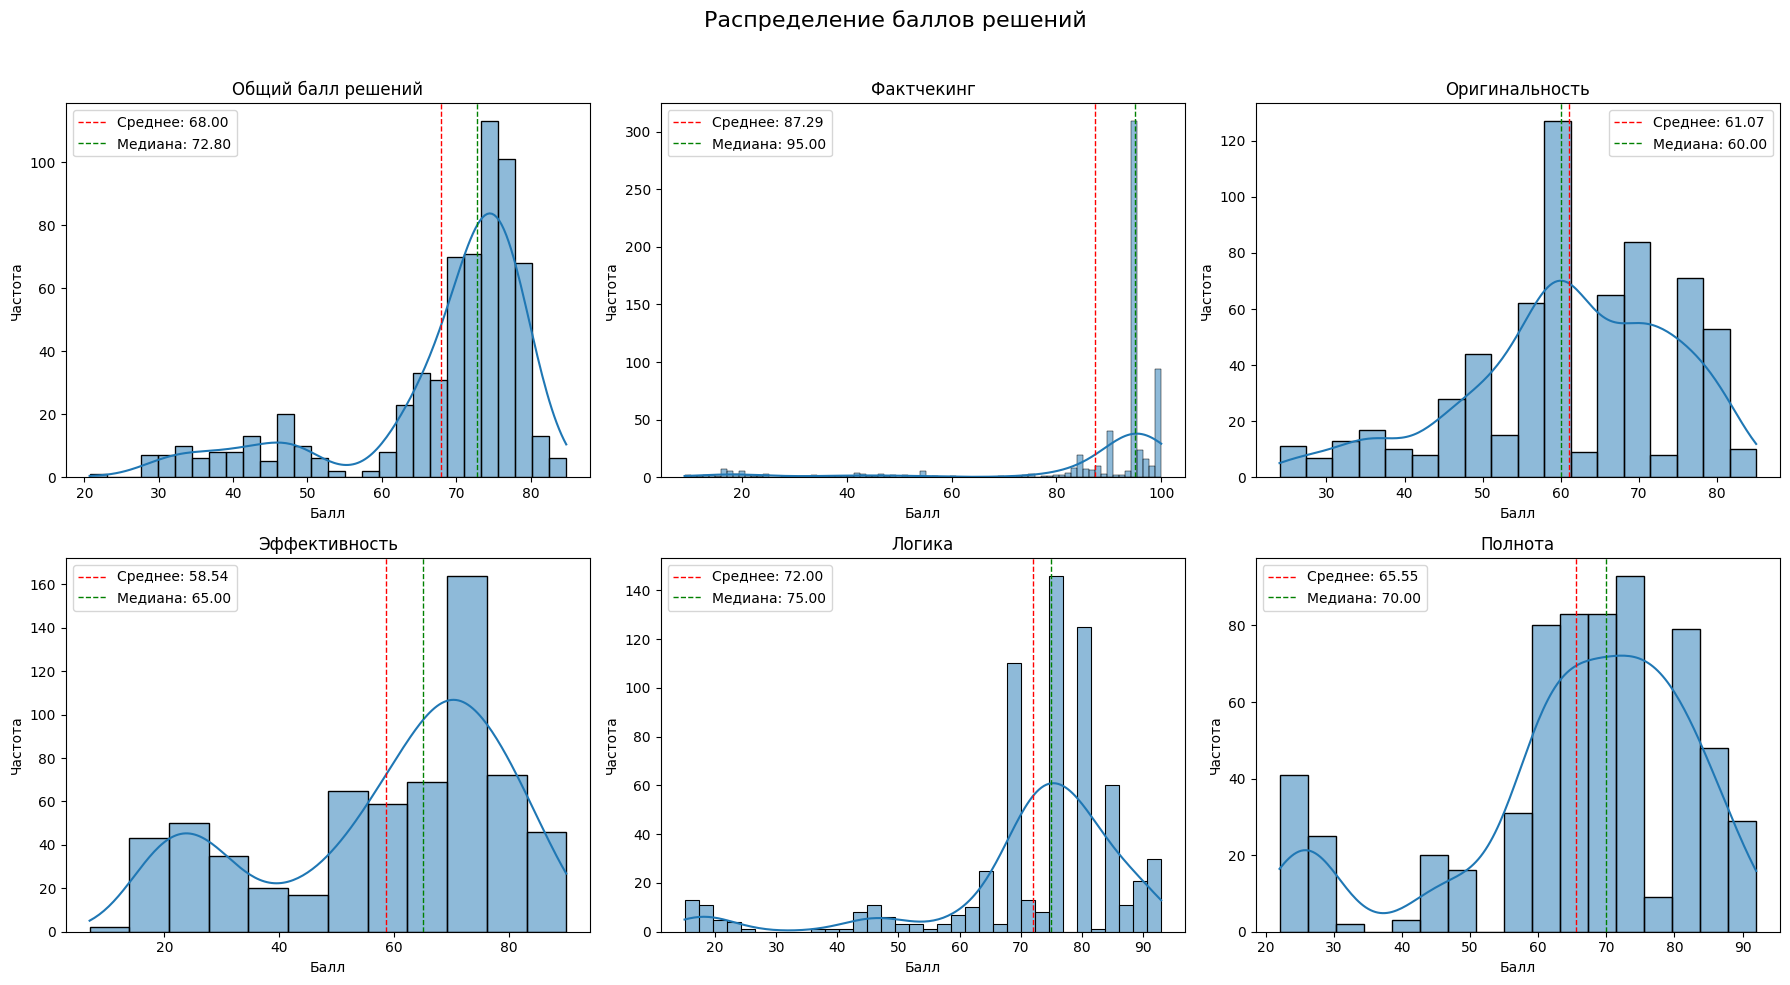

In [13]:
score_columns = {
    'score_total': 'Общий балл решений',
    'score_factchecking': 'Фактчекинг',
    'score_originality': 'Оригинальность',
    'score_effectiveness': 'Эффективность',
    'score_logic': 'Логика',
    'score_completeness': 'Полнота',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (column, title) in zip(axes.flat, score_columns.items()):
    sns.histplot(data=df, x=column, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Балл")
    ax.set_ylabel("Частота")
    ax.axvline(df[column].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Среднее: {df[column].mean():.2f}')
    ax.axvline(df[column].median(), color='green', linestyle='dashed', linewidth=1, label=f'Медиана: {df[column].median():.2f}')
    ax.legend()

fig.suptitle("Распределение баллов решений", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [14]:
SCORES = score_columns.keys()

In [15]:
real = df.loc[df['origin'] == 'real'].copy()
real.shape

(438, 13)

In [16]:
MODEL_COLS = ['case_id', 'case_title', 'case_text', 'solution_text'] + list(SCORES)
real_df = real[MODEL_COLS].copy()
model_df = df[MODEL_COLS].copy()

Разделяем на train, val, test, чтобы все решения по одному кейсу находились в одной выборке (чтобы избежать утечки) и с максимально похожим распределением выборок

In [17]:
def make_train_test_split(random_state=42):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=random_state)
    train_idx, test_idx = next(gss_test.split(real_df, groups=real_df['case_id']))
    trainval_df = real_df.iloc[train_idx]
    test_df = real_df.iloc[test_idx]
    gss_val = GroupShuffleSplit(n_splits=1, test_size=15/85, random_state=random_state+1000)
    train_idx, val_idx = next(gss_val.split(trainval_df, groups=trainval_df['case_id']))
    val_df = trainval_df.iloc[val_idx]
    train_df = trainval_df.iloc[train_idx]
    return train_df, val_df, test_df

In [18]:
def split_quality(train, val, test):
    global_mean = real_df[SCORES].mean()
    global_std = real_df[SCORES].std().replace(0, 1)

    score = 0

    # Насколько средние баллы выборок отличаются
    # от общего распределения
    for part in [train, val, test]:
        diff = (
            (part[SCORES].mean() - global_mean)
            / global_std
        ).abs()

        score += diff.mean()

    # Штраф за сильно неправильные размеры
    row_ratios = np.array([
        len(train) / len(real_df),
        len(val) / len(real_df),
        len(test) / len(real_df),
    ])

    target = np.array([0.70, 0.15, 0.15])

    score += np.abs(row_ratios - target).sum() * 2

    return score

In [19]:
best = None

for seed in range(2000):
    train_real, val, test = make_train_test_split(random_state=seed)

    quality = split_quality(train_real, val, test)

    if best is None or quality < best[0]:
        best = (
            quality,
            seed,
            train_real,
            val,
            test,
        )

quality, seed, train_real, val, test = best

print("Best seed:", seed)
print("Quality:", quality)

Best seed: 1537
Quality: 0.1770711569707118


In [20]:
train_case_ids = set(train_real['case_id'].unique())
train_synthetic = df.loc[
    df['case_id'].isin(train_case_ids) & (df['origin'] == 'synthetic'),
    MODEL_COLS,
].copy()
train = pd.concat([train_real, train_synthetic], ignore_index=True)

assert len(train) == len(train_real) + len(train_synthetic)
{
    'train_real': train_real.shape,
    'train_synthetic': train_synthetic.shape,
    'train_total': train.shape,
    'val': val.shape,
    'test': test.shape,
}

{'train_real': (309, 10),
 'train_synthetic': (144, 10),
 'train_total': (453, 10),
 'val': (67, 10),
 'test': (62, 10)}

In [21]:
for name, part in [
    ("TRAIN REAL", train_real),
    ("VAL", val),
    ("TEST", test),
]:
    print("\n", name)
    print(part[SCORES].mean().round(1))


 TRAIN REAL
score_total            73.7
score_factchecking     95.5
score_originality      65.5
score_effectiveness    65.5
score_logic            76.1
score_completeness     69.3
dtype: float64

 VAL
score_total            73.6
score_factchecking     94.7
score_originality      65.8
score_effectiveness    65.0
score_logic            76.5
score_completeness     69.6
dtype: float64

 TEST
score_total            74.2
score_factchecking     95.2
score_originality      66.7
score_effectiveness    66.5
score_logic            75.7
score_completeness     69.7
dtype: float64


In [22]:
train.to_csv("data/solution_evaluation/model/train.csv", index=False)
val.to_csv("data/solution_evaluation/model/val.csv", index=False)
test.to_csv("data/solution_evaluation/model/test.csv", index=False)

## Обучение модели

In [23]:
X_cols = ['case_title', 'case_text', 'solution_text']
Y_cols = list(SCORES)
Y_cols.remove('score_total') 

In [24]:
X_train = train[X_cols]
y_train = train[Y_cols]
X_val = val[X_cols]
y_val = val[Y_cols]
X_test = test[X_cols]
y_test = test[Y_cols]

### 0. Самый примитивный бэйзлайн

In [25]:
y_train_median = np.median(y_train, axis=0)  
y_pred = np.tile(y_train_median, (X_test.shape[0], 1))
metrics_dumb = {
    'MSE': [],
    'MAE': [],
    'R2': []
}
for i in range(len(Y_cols)):
    y_test_col = y_test.iloc[:, i]
    y_pred_col = y_pred[:, i]
    metrics_dumb['MSE'].append(sklearn.metrics.mean_squared_error(y_test_col, y_pred_col))
    metrics_dumb['MAE'].append(sklearn.metrics.mean_absolute_error(y_test_col, y_pred_col))
    metrics_dumb['R2'].append(sklearn.metrics.r2_score(y_test_col, y_pred_col))
metrics_df =pd.DataFrame(metrics_dumb, index=Y_cols).round(4)
metrics_df['model'] = 'DUMB'
print("DUMB MODEL METRICS:")
metrics_df

DUMB MODEL METRICS:


,MSE,MAE,R2,model
score_factchecking,17.3387,2.3387,-0.0034,DUMB
score_originality,139.1129,9.7581,-0.4751,DUMB
score_effectiveness,109.2742,8.1452,-0.0220,DUMB
score_logic,26.2097,3.6290,-0.0205,DUMB
score_completeness,93.5484,7.9032,-0.0011,DUMB


### 1. TF-IDF + регрессия

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

In [27]:
X_train_text = (
    'Заголовок кейса: ' + X_train['case_title'].fillna('')
    + '\nОписание кейса: ' + X_train['case_text'].fillna('')
    + '\nРешение: ' + X_train['solution_text'].fillna('')
)
X_test_text = (
    'Заголовок кейса: ' + X_test['case_title'].fillna('')
    + '\nОписание кейса: ' + X_test['case_text'].fillna('')
    + '\nРешение: ' + X_test['solution_text'].fillna('')
)

tfidf_ridge_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('ridge', Ridge(random_state=42)),
])

In [28]:
param_distributions = {
    'tfidf__analyzer': ['word', 'char', 'char_wb'],
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3), (2, 3), (2, 4), (3, 5)],
    'tfidf__max_features': [3000, 5000, 10000, 15000, 25000, 40000, None],
    'tfidf__min_df': [1, 2, 3, 5, 8, 10],
    'tfidf__max_df': [0.7, 0.8, 0.9, 0.95, 1.0],
    'tfidf__sublinear_tf': [True, False],
    'tfidf__use_idf': [True, False],
    'tfidf__binary': [True, False],
    'tfidf__norm': ['l1', 'l2'],
    'ridge__alpha': np.logspace(-3, 3, 25),
    'ridge__fit_intercept': [True, False],
    'ridge__solver': ['lsqr', 'sparse_cg'],
    'ridge__tol': [1e-5, 1e-4, 1e-3, 1e-2],
}

In [ ]:
group_cv = GroupKFold(n_splits=4)

tfidf_ridge_search = RandomizedSearchCV(
    estimator=tfidf_ridge_pipeline,
    param_distributions=param_distributions,
    n_iter=160,
    scoring='neg_mean_absolute_error',
    cv=group_cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True,
    error_score='raise',
)

tfidf_ridge_search.fit(
    X_train_text,
    y_train,
    groups=train['case_id'],
)

print('Лучший CV MAE:', round(-tfidf_ridge_search.best_score_, 4))
print('Лучшие параметры:')
tfidf_ridge_search.best_params_

TOTAL_SCORE_WEIGHTS = {
    'score_factchecking': 0.20,
    'score_originality': 0.25,
    'score_effectiveness': 0.25,
    'score_logic': 0.15,
    'score_completeness': 0.15,
}
y_pred_tfidf = pd.DataFrame(
    np.clip(tfidf_ridge_search.predict(X_test_text), 0, 100),
    columns=Y_cols,
    index=y_test.index,
)
y_test_with_total = y_test.copy()
y_test_with_total['score_total'] = sum(
    y_test_with_total[column] * weight
    for column, weight in TOTAL_SCORE_WEIGHTS.items()
).round(1)

y_pred_tfidf_with_total = y_pred_tfidf.copy()
y_pred_tfidf_with_total['score_total'] = sum(
    y_pred_tfidf_with_total[column] * weight
    for column, weight in TOTAL_SCORE_WEIGHTS.items()
).round(1)

MODEL_NAME = 'TFIDF_RIDGE_RANDOM_SEARCH'
metric_rows = []
for score_column in Y_cols + ['score_total']:
    metric_rows.append({
        'score': score_column,
        'MSE': mean_squared_error(
            y_test_with_total[score_column],
            y_pred_tfidf_with_total[score_column],
        ),
        'MAE': mean_absolute_error(
            y_test_with_total[score_column],
            y_pred_tfidf_with_total[score_column],
        ),
        'R2': r2_score(
            y_test_with_total[score_column],
            y_pred_tfidf_with_total[score_column],
        ),
        'model': MODEL_NAME,
    })

tfidf_metrics = pd.DataFrame(metric_rows).set_index('score').round(4)
metrics_df = metrics_df.loc[metrics_df['model'] != MODEL_NAME]
metrics_df = pd.concat([metrics_df, tfidf_metrics])
metrics_df

Fitting 4 folds for each of 160 candidates, totalling 640 fits
Лучший CV MAE: 10.9006
Лучшие параметры:


,MSE,MAE,R2,model
score_factchecking,17.3387,2.3387,-0.0034,DUMB
score_originality,139.1129,9.7581,-0.4751,DUMB
score_effectiveness,109.2742,8.1452,-0.0220,DUMB
score_logic,26.2097,3.6290,-0.0205,DUMB
score_completeness,93.5484,7.9032,-0.0011,DUMB
score_factchecking,47.5810,5.3796,-1.7535,TFIDF_RIDGE_RANDOM_SEARCH
score_originality,104.0246,8.5278,-0.1030,TFIDF_RIDGE_RANDOM_SEARCH
score_effectiveness,84.7401,6.8805,0.2075,TFIDF_RIDGE_RANDOM_SEARCH
score_logic,19.4215,3.5175,0.2438,TFIDF_RIDGE_RANDOM_SEARCH
score_completeness,58.3635,6.1132,0.3754,TFIDF_RIDGE_RANDOM_SEARCH


: 

## Экспорт моделей в joblib

In [ ]:
from pathlib import Path

import joblib

ARTIFACTS_DIR = Path('../artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

dumb_artifact = {
    'model_name': 'DUMB',
    'model_type': 'median_baseline',
    'median_scores': dict(zip(Y_cols, y_train_median.tolist())),
    'target_columns': Y_cols,
    'total_score_weights': TOTAL_SCORE_WEIGHTS,
}

tfidf_ridge_artifact = {
    'model_name': MODEL_NAME,
    'model': tfidf_ridge_search.best_estimator_,
    'input_columns': X_cols,
    'target_columns': Y_cols,
    'total_score_weights': TOTAL_SCORE_WEIGHTS,
    'best_params': tfidf_ridge_search.best_params_,
    'best_cv_mae': -tfidf_ridge_search.best_score_,
}

exported_models = {
    'dumb_baseline': ARTIFACTS_DIR / 'evaluation_dumb_baseline.joblib',
    'tfidf_ridge': ARTIFACTS_DIR / 'evaluation_tfidf_ridge.joblib',
}

joblib.dump(dumb_artifact, exported_models['dumb_baseline'])
joblib.dump(tfidf_ridge_artifact, exported_models['tfidf_ridge'])

{name: str(path.resolve()) for name, path in exported_models.items()}